# Forecasting Credit Card Spending for Personalized Customer Relationship Management: A Predictive Analysis

## Jessenth Ebenezer S - 15154 (GET-TVSM)

<p>In this notebook, we will address the challenge of predicting the average credit card spending for a set of customers over the next three months (July, August, and September). Accurate predictions of consumer spending patterns are vital for banks, enabling them to tailor their services and marketing strategies effectively. To achieve this, we will explore customer demographics, financial information, and past transaction history to build a predictive model. This model will assist XYZ Bank in making informed decisions to enhance customer relationship management and strategic planning.</p>

<h4> We will be using Python as our base language, and frameworks such as NumPy, Pandas, Seaborn, Sklearn, etc for our data analysis, visualization, prediction, validation and testing. </h4>

### Importing Packages

In [59]:
#importing packages and libraries that are required for this project
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec  
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import HuberRegressor, Lasso, Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor



### Data Exploration and Initial Analysis

In [2]:
#importing training and evaluation datasets and configuring pandas to show max columns
raw=pd.read_csv("train.csv")
test_raw=pd.read_csv("test_9K3DBWQ_2aRGUxy.csv")
pd.set_option('display.max_columns', 1000);
pd.set_option('display.max_rows', 1000);

In [3]:
#understanding the feature descriptions:
data_desc = pd.read_excel("Data_Dictionary.xlsx")
data_desc

,Variable,Description
0,id,Unique ID for every Customer
1,account_type,Account Type – current or saving
2,gender,Gender of customer
3,age,Age of customer
4,region_code,Code assigned to region of residence (has order)
5,cc_cons_apr,Credit card spend in April
6,dc_cons_apr,Debit card spend in April
7,cc_cons_may,Credit card spend in May
8,dc_cons_may,Debit card spend in May
9,cc_cons_jun,Credit card spend in June


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32820 entries, 0 to 32819
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     32820 non-null  int64  
 1   account_type           32820 non-null  object 
 2   gender                 32820 non-null  object 
 3   age                    32820 non-null  int64  
 4   region_code            32820 non-null  int64  
 5   cc_cons_apr            32820 non-null  float64
 6   dc_cons_apr            13768 non-null  float64
 7   cc_cons_may            32820 non-null  float64
 8   dc_cons_may            15481 non-null  float64
 9   cc_cons_jun            32820 non-null  float64
 10  dc_cons_jun            11523 non-null  float64
 11  cc_count_apr           30421 non-null  float64
 12  cc_count_may           31667 non-null  float64
 13  cc_count_jun           31230 non-null  float64
 14  dc_count_apr           13768 non-null  float64
 15  dc

In [5]:
raw.describe()

,id,age,region_code,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,dc_count_apr,dc_count_may,dc_count_jun,card_lim,personal_loan_active,vehicle_loan_active,personal_loan_closed,vehicle_loan_closed,investment_1,investment_2,investment_3,investment_4,debit_amount_apr,credit_amount_apr,debit_count_apr,credit_count_apr,max_credit_amount_apr,debit_amount_may,credit_amount_may,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons
count,32820.000000,32820.000000,32820.000000,32820.000000,13768.000000,3.282000e+04,15481.000000,32820.000000,11523.000000,30421.000000,31667.000000,31230.000000,13768.000000,15481.000000,17323.000000,32811.000000,2742.0,846.0,2883.0,1625.0,1.426000e+03,2.338000e+03,1.332000e+03,406.000000,3.093000e+04,2.951800e+04,31062.000000,31062.000000,2.951800e+04,3.051900e+04,2.941500e+04,30749.000000,30749.000000,2.941500e+04,3.062500e+04,3.127700e+04,31292.000000,31292.000000,3.127700e+04,3.282000e+04,32820.000000
mean,23450.929616,35.951676,554.854327,16661.907189,5727.615837,1.441190e+04,5635.506904,9031.179889,4666.713420,9.162191,9.540184,12.298687,5.256900,6.267618,7.897016,121553.749657,1.0,1.0,1.0,1.0,8.115118e+05,1.765459e+05,3.975786e+04,4972.642169,7.002974e+04,7.541190e+04,14.887290,3.791771,4.647113e+04,6.709618e+04,7.959347e+04,4.087352,13.934795,4.969688e+04,7.759673e+04,7.583531e+04,5.767736,16.001438,4.474355e+04,9.567620e+03,6824.631840
std,13495.676061,8.529949,188.220317,25138.435416,11544.058014,2.363688e+04,14052.343253,15720.847307,10265.189742,10.790714,9.648387,11.714253,6.147011,7.380032,9.197672,123019.826520,0.0,0.0,0.0,0.0,4.418812e+06,4.403071e+05,8.430780e+04,6107.212042,1.641944e+05,1.777199e+05,11.589652,3.482266,1.181413e+05,1.855331e+05,2.026879e+05,3.847766,11.455178,1.287256e+05,3.140103e+05,3.062791e+05,4.704716,13.370195,1.215379e+05,2.616736e+05,12459.140593
min,0.000000,22.000000,123.000000,233.970000,10.010000,1.030000e+02,20.000000,51.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.0,1.0,1.0,1.0,2.000000e-02,3.000000e+00,0.000000e+00,-12179.000000,4.010000e+00,3.432000e+01,0.000000,0.000000,1.800000e-01,1.500000e-01,1.061000e+01,0.000000,0.000000,1.500000e-01,5.230000e+00,1.188000e+01,0.000000,0.000000,6.000000e-02,0.000000e+00,0.000000
25%,11824.750000,31.000000,425.000000,3712.000000,849.000000,2.983298e+03,796.000000,1637.875000,743.000000,3.000000,3.000000,4.000000,1.000000,2.000000,2.000000,45000.000000,1.0,1.0,1.0,1.0,4.885100e+03,3.500000e+04,6.971250e+03,977.000000,2.229260e+04,2.531025e+04,6.000000,2.000000,1.800000e+04,2.010401e+04,2.467500e+04,2.000000,6.000000,1.817300e+04,2.509642e+04,2.306400e+04,3.000000,6.000000,1.600000e+04,0.000000e+00,1285.000000
50%,23478.500000,34.000000,575.000000,8912.790000,2282.160000,7.332298e+03,2129.000000,4147.487500,1832.000000,7.000000,7.000000,9.000000,3.000000,4.000000,5.000000,75000.000000,1.0,1.0,1.0,1.0,3.289308e+04,8.500000e+04,2.500000e+04,5427.500000,4.114024e+04,4.394596e+04,12.000000,3.000000,2.813100e+04,3.836849e+04,4.538700e+04,3.000000,11.000000,3.000000e+04,4.593499e+04,4.295500e+04,5.000000,13.000000,2.687600e+04,1.510650e+02,3141.000000
75%,35096.250000,39.000000,683.000000,19932.060000,6074.600000,1.684785e+04,5640.000000,10126.250000,4607.500000,12.000000,13.000000,17.000000,7.000000,8.000000,10.000000,145000.000000,1.0,1.0,1.0,1.0,1.748331e+05,1.763457e+05,5.000000e+04,6885.000000,7.541069e+04,7.975369e+04,20.000000,5.000000,4.800000e+04,7.373561e+04,8.917050e+04,5.000000,19.000000,5.000000e+04,8.413612e+04,8.072400e+04,7.000000,22.000000,4.701000e+04,4.176868e+03,7349.250000
max,46886.000000,224.000000,977.000000,804712.580000,366223.160000,1.117246e+06,911223.490000,382914.100000,301991.940000,1012.000000,601.000000,653.000000,82.000000,97.000000,104.000000,1000000.000000,1.0,1.0,1.0,1.0,8.445222e+07,

In [6]:
raw.corr()

/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/3981158159.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  raw.corr()


,id,age,region_code,cc_cons_apr,dc_cons_apr,cc_cons_may,dc_cons_may,cc_cons_jun,dc_cons_jun,cc_count_apr,cc_count_may,cc_count_jun,dc_count_apr,dc_count_may,dc_count_jun,card_lim,personal_loan_active,vehicle_loan_active,personal_loan_closed,vehicle_loan_closed,investment_1,investment_2,investment_3,investment_4,debit_amount_apr,credit_amount_apr,debit_count_apr,credit_count_apr,max_credit_amount_apr,debit_amount_may,credit_amount_may,credit_count_may,debit_count_may,max_credit_amount_may,debit_amount_jun,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons
id,1.000000,0.001639,0.003658,0.000364,-0.003566,-0.002718,-0.002323,0.002291,-0.011750,-0.004069,0.003123,0.001777,0.001897,0.002347,0.007439,0.001180,NaN,NaN,NaN,NaN,0.020765,-0.014462,-0.025582,0.049960,-0.003578,-0.002439,0.000950,-0.009687,0.000741,-0.000311,0.000584,-0.006357,0.002339,0.000670,-0.002670,-0.003648,-0.013925,-0.001678,-0.004844,-0.007572,0.001431
age,0.001639,1.000000,-0.033487,0.120472,0.035335,0.088864,0.027562,0.102278,0.038806,0.009516,0.016150,0.038399,-0.114461,-0.121690,-0.123600,0.359100,NaN,NaN,NaN,NaN,-0.007976,0.135000,0.243388,0.259958,0.081769,0.092816,-0.174895,-0.078496,0.090173,0.066115,0.079843,-0.095974,-0.156123,0.089718,0.043599,0.041543,-0.126555,-0.175591,0.068314,0.030589,0.091187
region_code,0.003658,-0.033487,1.000000,-0.000427,0.005897,-0.013855,-0.030376,-0.006608,-0.016264,0.024232,0.024924,0.008169,0.046970,0.033969,0.019076,-0.025955,NaN,NaN,NaN,NaN,-0.001823,-0.004338,-0.012502,-0.104061,0.005053,-0.005582,0.096133,0.030649,0.003312,0.001009,-0.008885,0.055928,0.089485,-0.011234,-0.004277,-0.003681,0.030060,0.077364,-0.000260,0.004425,0.011888
cc_cons_apr,0.000364,0.120472,-0.000427,1.000000,0.081402,0.418922,0.055649,0.382849,0.056609,0.406129,0.275307,0.266234,-0.033555,-0.020075,-0.025552,0.313055,NaN,NaN,NaN,NaN,0.016723,0.111695,0.126579,0.132539,0.179771,0.184229,-0.017497,0.095116,0.141922,0.188761,0.169576,0.090587,-0.003871,0.143256,0.114007,0.115629,0.059279,-0.026238,0.130187,0.041961,0.319911
dc_cons_apr,-0.003566,0.035335,0.005897,0.081402,1.000000,0.068272,0.211469,0.071348,0.161190,-0.018971,0.002320,0.023860,0.373446,0.240684,0.202871,0.071596,NaN,NaN,NaN,NaN,0.059842,0.020314,0.078308,0.294886,0.219877,0.196161,0.250722,0.109659,0.165483,0.111062,0.097851,0.059047,0.184416,0.088825,0.097719,0.098844,0.039992,0.154589,0.085783,0.017547,0.081675
cc_cons_may,-0.002718,0.088864,-0.013855,0.418922,0.068272,1.000000,0.104173,0.397809,0.092373,0.243632,0.414781,0.293499,0.002263,-0.009551,-0.010040,0.285865,NaN,NaN,NaN,NaN,-0.004694,0.123251,0.194105,0.164918,0.147499,0.146106,-0.007690,0.070918,0.114636,0.166913,0.157050,0.093778,0.011867,0.131391,0.121210,0.118804,0.060696,-0.012234,0.137711,0.028935,0.328249
dc_cons_may,-0.002323,0.027562,-0.030376,0.055649,0.211469,0.104173,1.000000,0.077316,0.239142,0.006994,-0.014517,-0.004806,0.161707,0.312530,0.193729,0.048411,NaN,NaN,NaN,NaN,0.007056,0.173010,0.100452,0.057180,0.069123,0.088462,0.106724,0.053137,0.061074,0.267920,0.194846,0.115126,0.239050,0.163014,0.123126,0.108375,0.055952,0.151923,0.077233,0.003760,0.104321
cc_cons_jun,0.002291,0.102278,-0.006608,0.382849,0.071348,0.397809,0.077316,1.000000,0.148500,0.144363,0.178504,0.216340,0.003061,0.002858,-0.007633,0.245745,NaN,NaN,NaN,NaN,0.000229,0.093322,0.131230,0.121491,0.154730,0.149121,-0.017932,0.052634,0.124754,0.148033,0.145851,0.064632,0.004316,0.127722,0.112644,0.114291,0.037305,-0.014340,0.133351,0.025266,0.379366
dc_cons_jun,-0.011750,0.038806,-0.016264,0.056609,0.161190,0.092373,0.239142,0.148500,1.000000,0.027921,0.035825,0.003286,0.146664,0.191923,0.269136,0.053447,NaN,NaN,NaN,NaN,0.063999,0.113688,0.041500,0.102637,0.083821,0.089379,0.080287,0.031866,0.077447,0.107770,0.143428,0.045794,0.128023,0.145380,0.227786,0.176929,0.055775,0.216546,0.137042,0.005969,0.092009
cc_count_apr,-0.004069,0.009516,0.024232,0.406129,-0.018971,0.243632,0.006994,0.144363,0.02792

### Exploratory Data Analysis (EDA)

In [7]:
def plotter(df, feature):
    
    fig = plt.figure(constrained_layout = True, figsize = (20, 5))
    grid = gridspec.GridSpec(ncols = 2, nrows = 2, figure = fig)

    #Histogram to analyse distribution
    ax1 = fig.add_subplot(grid[0, 0])
    ax1.set_title('Histogram')
    sns.distplot(df.loc[:, feature], norm_hist=True, ax=ax1, bins=50)
    plt.axvline(x=df[feature].mean(), c='red')
    plt.axvline(x=df[feature].median(), c='green')

    #Boxplot to analyse outlier information
    ax2 = fig.add_subplot(grid[1, 0])
    ax2.set_title('Box Plot')
    sns.boxplot(df.loc[:, feature], orient='h', ax=ax2)



/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/218870913.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:, feature], norm_hist=True, ax=ax1, bins=50)


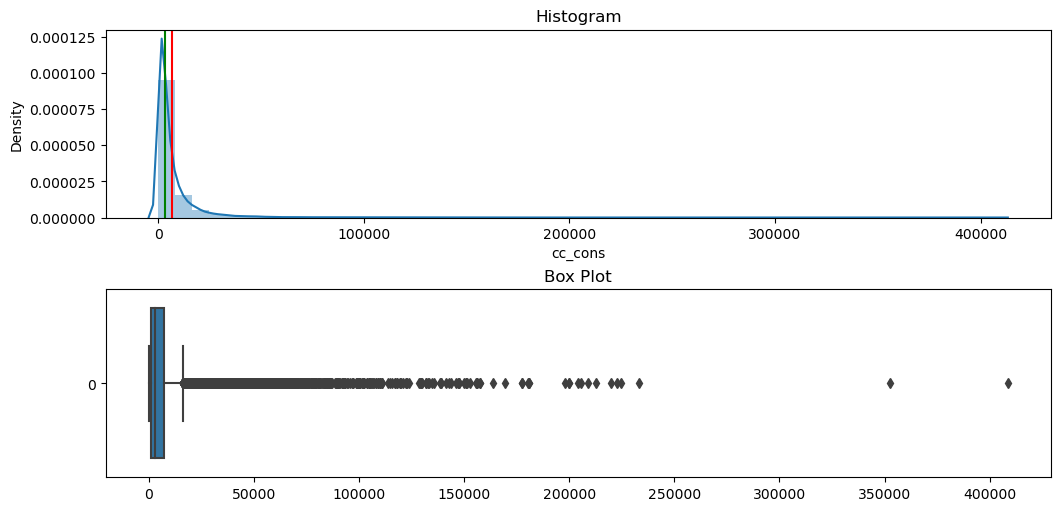

In [8]:
plotter(raw,"cc_cons")

In [ ]:
#we observe outliers exceeding 100,000 rupees, and hence can check if dropping them is feasible based on the number
#of such outliers in the dataset

/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/218870913.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:, feature], norm_hist=True, ax=ax1, bins=50)


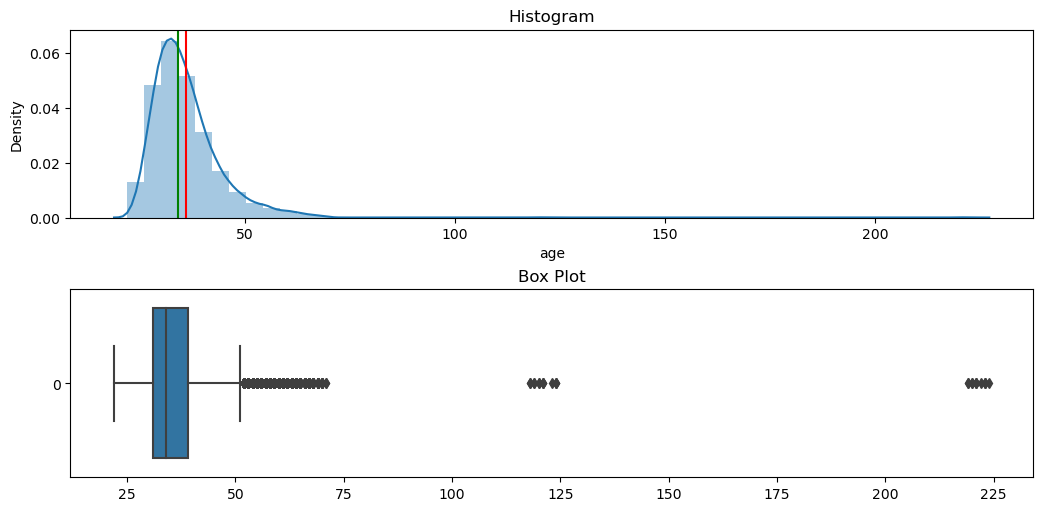

In [9]:
plotter(raw,"age")

In [ ]:
#we can clearly see that almost all the values are below 75 except for some unrealistic values, so we will
#proceed by dropping the rows with such information in the dataset

### Outlier Treatment

In [10]:
df=raw.copy()

In [12]:
df.loc[df['cc_cons'] >= 100000].shape


(96, 44)

In [13]:
df.loc[df['age'] >= 100 ].shape

(25, 44)

In [ ]:
#we can see that we have 96 and 25 rows respectively for age and target value outliers, which we can drop now.

In [14]:
df.drop(df[df['age'] >= 100].index, inplace = True)
df.drop(df[df['cc_cons'] >= 100000].index, inplace = True)

/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/218870913.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:, feature], norm_hist=True, ax=ax1, bins=50)


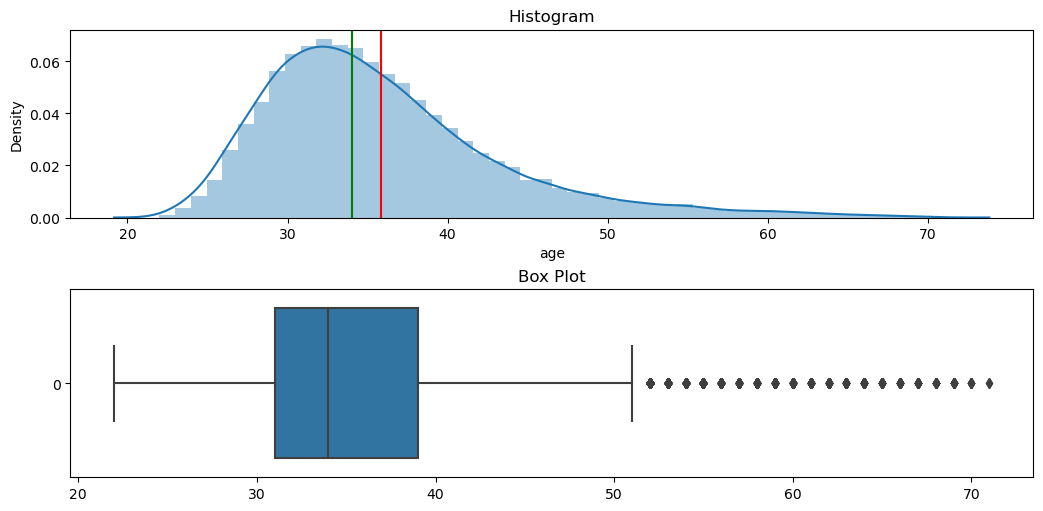

In [15]:
plotter(df,"age")

/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/218870913.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[:, feature], norm_hist=True, ax=ax1, bins=50)


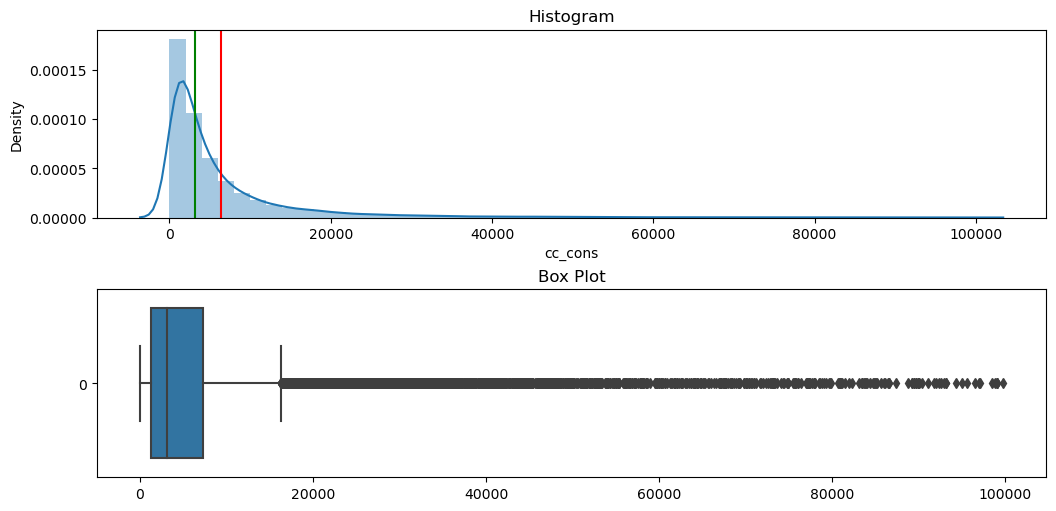

In [16]:
plotter(df,"cc_cons")

### Analyzing categorical features

In [ ]:
#from the data dictionary, the two categorical features we have are gender and account type, so lets visualize the info
#contained based on these two parameters.

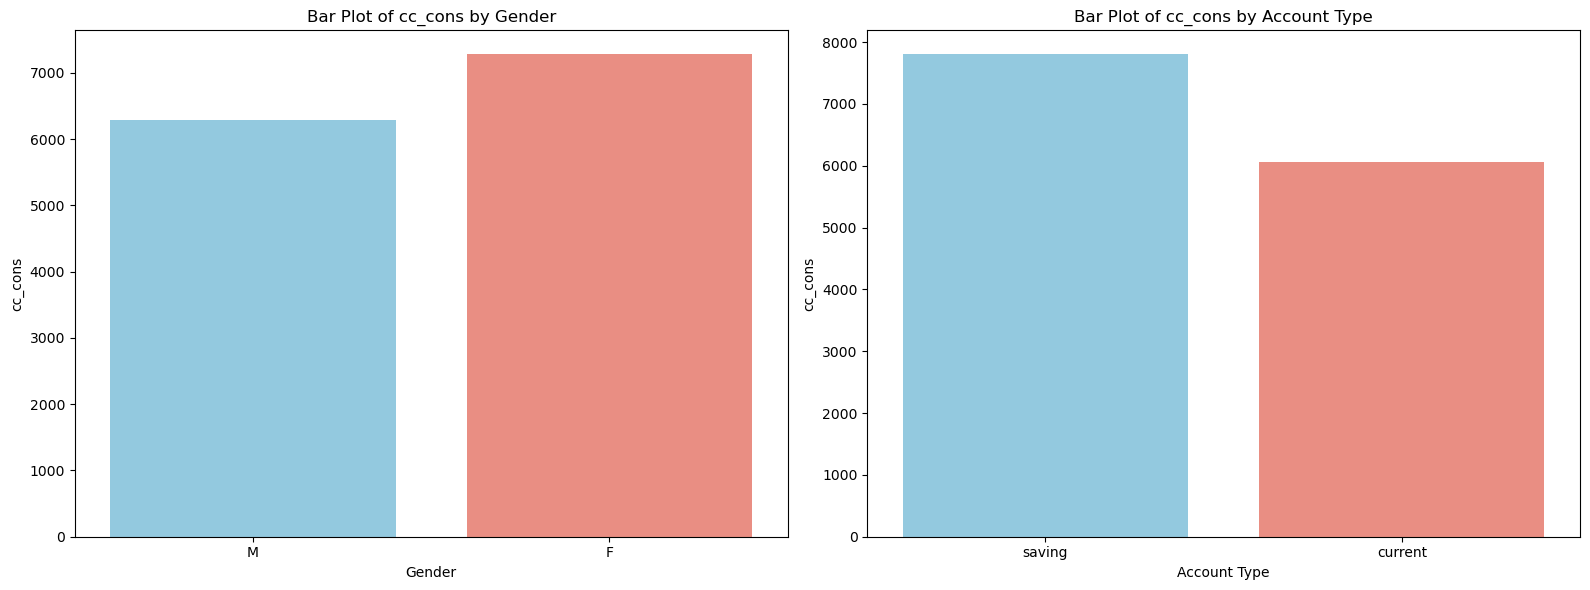

In [28]:

custom_palette = sns.color_palette(['skyblue', 'salmon','lightgreen','lightcoral','lightsteelblue','lightsalmon'])

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='gender', y='cc_cons', data=df, errorbar=None, palette=custom_palette)  
plt.title('Bar Plot of cc_cons by Gender')
plt.xlabel('Gender')
plt.ylabel('cc_cons')
plt.subplot(1, 2, 2)
sns.barplot(x='account_type', y='cc_cons', data=df, errorbar=None, palette=custom_palette) 
plt.title('Bar Plot of cc_cons by Account Type')
plt.xlabel('Account Type')
plt.ylabel('cc_cons')

plt.tight_layout()

plt.show()


<Axes: >

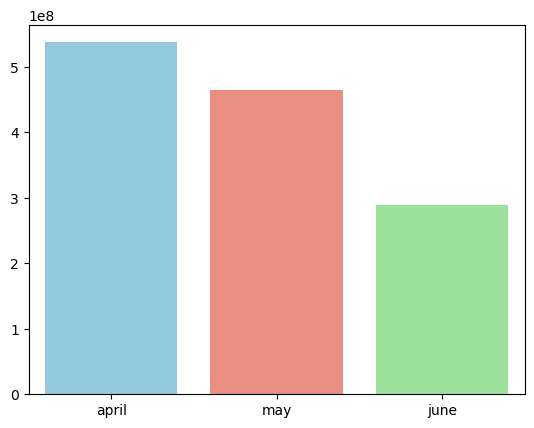

In [29]:
sns.barplot(x=["april", "may", "june"], y=[df["cc_cons_apr"].sum(), df['cc_cons_may'].sum(), df["cc_cons_jun"].sum()],palette=custom_palette)

<Axes: >

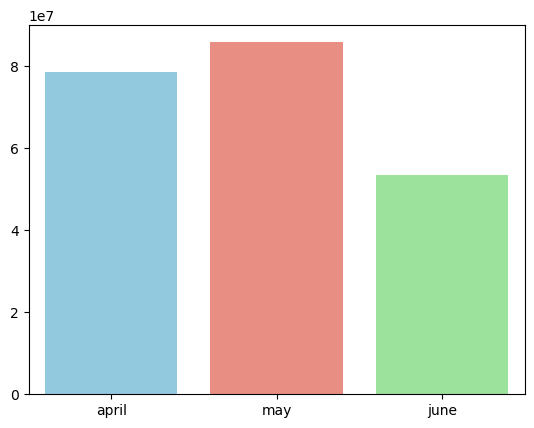

In [30]:
sns.barplot(x=["april", "may", "june"], y=[df["dc_cons_apr"].sum(), df['dc_cons_may'].sum(), df["dc_cons_jun"].sum()],palette=custom_palette)

In [ ]:
#the above two graphs look for seasonal spending patterns in credit and debit cards

### Handling Missing Values

In [ ]:
#checking for missing values

In [31]:
df.isnull().mean()*100

id                        0.000000
account_type              0.000000
gender                    0.000000
age                       0.000000
region_code               0.000000
cc_cons_apr               0.000000
dc_cons_apr              58.001774
cc_cons_may               0.000000
dc_cons_may              52.778372
cc_cons_jun               0.000000
dc_cons_jun              64.861311
cc_count_apr              7.302976
cc_count_may              3.510811
cc_count_jun              4.859476
dc_count_apr             58.001774
dc_count_may             52.778372
dc_count_jun             47.166580
card_lim                  0.027524
personal_loan_active     91.666412
vehicle_loan_active      97.421940
personal_loan_closed     91.247439
vehicle_loan_closed      95.067127
investment_1             95.678767
investment_2             92.895807
investment_3             95.957063
investment_4             98.764488
debit_amount_apr          5.752469
credit_amount_apr        10.043121
debit_count_apr     

In [ ]:
#we can see that there are a lot of missing values in the loan status columns, investment details
#and loan enquiry status, we will now visualize and handle these values

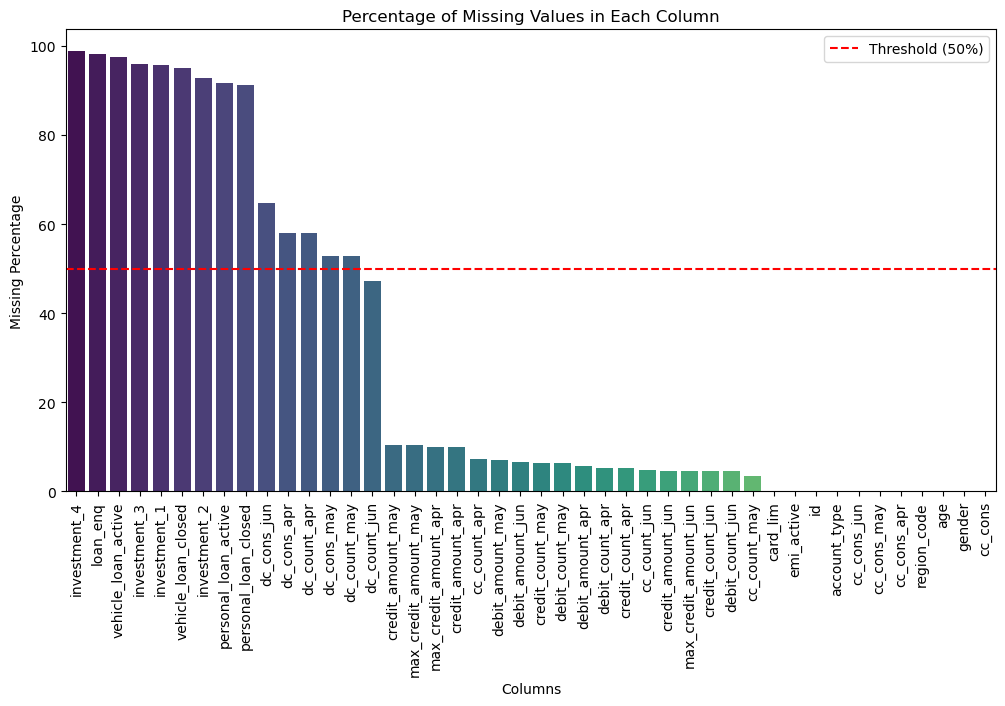

In [32]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Column': df.columns, 'MissingPercentage': missing_percentage})
missing_data = missing_data.sort_values(by='MissingPercentage', ascending=False)
threshold = 50

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Column', y='MissingPercentage', data=missing_data, palette='viridis')
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold}%)')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage')
plt.title('Percentage of Missing Values in Each Column')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [33]:
df.columns

Index(['id', 'account_type', 'gender', 'age', 'region_code', 'cc_cons_apr',
       'dc_cons_apr', 'cc_cons_may', 'dc_cons_may', 'cc_cons_jun',
       'dc_cons_jun', 'cc_count_apr', 'cc_count_may', 'cc_count_jun',
       'dc_count_apr', 'dc_count_may', 'dc_count_jun', 'card_lim',
       'personal_loan_active', 'vehicle_loan_active', 'personal_loan_closed',
       'vehicle_loan_closed', 'investment_1', 'investment_2', 'investment_3',
       'investment_4', 'debit_amount_apr', 'credit_amount_apr',
       'debit_count_apr', 'credit_count_apr', 'max_credit_amount_apr',
       'debit_amount_may', 'credit_amount_may', 'credit_count_may',
       'debit_count_may', 'max_credit_amount_may', 'debit_amount_jun',
       'credit_amount_jun', 'credit_count_jun', 'debit_count_jun',
       'max_credit_amount_jun', 'loan_enq', 'emi_active', 'cc_cons'],
      dtype='object')

### Feature Engineering

In [ ]:
#based on the dictionary and the results of EDA, we start feature engineering

In [34]:
df["investment"] = df[['investment_1', 'investment_2', 'investment_3', 'investment_4']].sum(axis=1)
df["total_active_loan"] = df[['personal_loan_active', 'vehicle_loan_active']].sum(axis=1)
df["total_closed_loan"] = df[['personal_loan_closed', 'vehicle_loan_closed']].sum(axis=1)

In [35]:
df['cc_cons_old'] = df[['cc_cons_apr', 'cc_cons_may', 'cc_cons_jun']].mean(axis=1)
df['dc_cons'] = df[['dc_cons_apr', 'dc_cons_may', 'dc_cons_jun']].mean(axis=1)
df['cc_count'] = df[['cc_count_apr', 'cc_count_may', 'cc_count_jun']].mean(axis=1)
df['dc_count'] = df[['dc_count_apr', 'dc_count_may', 'dc_count_jun']].mean(axis=1)
df['debit_amount'] = df[['debit_amount_apr', 'debit_amount_may', 'debit_amount_jun']].mean(axis=1)
df['credit_amount'] = df[['credit_amount_apr', 'credit_amount_may', 'credit_amount_jun']].mean(axis=1)
df['max_credit_amount'] = df[['max_credit_amount_apr', 'max_credit_amount_may', 'max_credit_amount_jun']].mean(axis=1)
df['debit_count'] = df[['debit_count_apr', 'debit_count_may', 'debit_count_jun']].mean(axis=1)
df['credit_count'] = df[['credit_count_apr', 'credit_count_may', 'credit_count_jun']].mean(axis=1)

In [ ]:
#we have combined investment data, loan information and aggregated the credit and debit card spends of 
#3 months into a single column for cc and dc respectively, same with the count and total amount

In [39]:
cols_to_delete = ['investment_1',
                    'investment_2',
                    'investment_3',
                    'investment_4',
                    'personal_loan_active',
                    'vehicle_loan_active',
                    'personal_loan_closed',
                    'vehicle_loan_closed',
                    'cc_cons_apr',
                    'cc_cons_may',
                    'cc_cons_jun',
                    'dc_cons_apr',
                    'dc_cons_may',
                    'dc_cons_jun',
                    'cc_count_apr',
                    'cc_count_may',
                    'cc_count_jun',
                    'dc_count_apr',
                    'dc_count_may',
                    'dc_count_jun',
                    'debit_amount_apr',
                    'debit_amount_may',
                    'debit_amount_jun',
                    'credit_amount_apr',
                    'credit_amount_may',
                    'credit_amount_jun',
                    'max_credit_amount_apr',
                    'max_credit_amount_may',
                    'max_credit_amount_jun',
                    'debit_count_apr',
                    'debit_count_may',
                    'debit_count_jun',
                    'credit_count_apr',
                    'credit_count_may',
                    'credit_count_jun'
                    ]

In [40]:
df = df.drop(columns = cols_to_delete)

In [41]:
df.shape

(32699, 21)

In [ ]:
#now the dataset contains 21 columns, compared to the 44 that we started with

In [ ]:
#we will apply the same feature engineering steps on the evaluation dataset later

In [ ]:
#With domain knowledge, we can make the educated assumption that the missing values in the dataset, especially
#in places like debit card spend, can be imputed to 0

In [42]:
na_cols = list(df.columns[df.isnull().any()].values)
na_cols

['card_lim',
 'loan_enq',
 'dc_cons',
 'dc_count',
 'debit_amount',
 'credit_amount',
 'max_credit_amount',
 'debit_count',
 'credit_count']

In [43]:
df.fillna(0, inplace = True)

In [46]:

label_encoder = LabelEncoder()

df['gender_enc'] = label_encoder.fit_transform(df['gender'])
#1 is male, 0 is female

df['ac_type']=label_encoder.fit_transform(df['account_type'])
#savings is 1, current is 0



In [64]:

df['loan_enq'].fillna(0, inplace=True)

df['loan_enq'].replace(to_replace=dict(Y=1, NaN=0), inplace=True)

In [48]:
#rearranging the columns of the dataset
df=df.drop(["account_type","gender"],axis=1)

desired_order = ['id', 'gender_enc', 'ac_type'] + [col for col in df.columns if col not in ['id', 'gender_enc', 'ac_type']]

df=df[desired_order]

df.head()


,id,gender_enc,ac_type,age,region_code,card_lim,loan_enq,emi_active,cc_cons,investment,total_active_loan,total_closed_loan,cc_cons_old,dc_cons,cc_count,dc_count,debit_amount,credit_amount,max_credit_amount,debit_count,credit_count
0,23334,1,1,63,305,150000.0,0,0.00,435,168845.2,0.0,0.0,2932.000000,0.00,2.0,0.000000,32053.846667,55263.456667,31823.333333,2.666667,3.666667
1,20329,1,0,33,326,176000.0,0,4963.33,1921,0.0,0.0,1.0,27887.333333,1897.48,12.0,3.500000,128063.756667,133269.333333,82333.333333,16.333333,7.666667
2,17679,1,0,44,264,65000.0,0,0.00,1970,0.0,0.0,0.0,11209.376667,1725.84,7.0,6.333333,37864.850000,30430.303333,15433.333333,14.000000,4.000000
3,16428,1,1,44,233,600000.0,0,1238.18,21579,132442.0,0.0,0.0,11602.833333,0.00,7.0,0.000000,8922.953333,9789.000000,8866.666667,1.333333,1.666667
4,18721,0,1,35,324,100000.0,0,0.00,1814,0.0,0.0,0.0,1928.373333,0.00,6.0,0.000000,13367.016667,22316.000000,19333.333333,4.333333,2.333333


### Correlation Matrix after data preprocessing

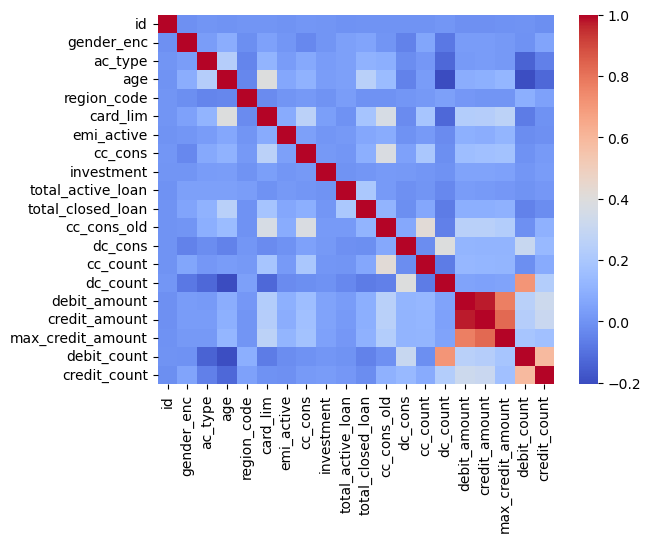

In [53]:
cm = df.corr(numeric_only=True)

sns.heatmap(cm, cmap='coolwarm')
plt.show()

## Model Training and Testing


In [ ]:
#Training various models

In [ ]:
#Here, we have chosen a few regressor models to test them out on the dataset, we will also be checking the root 
#mean squared logarithmic error as that is the project's evaluation metric, with a threshold of 125 to beat.


In [67]:
X = df.drop(['id', 'cc_cons'], axis=1)
Y = df['cc_cons']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize and train various regression models
models = {
    "Huber Regressor": HuberRegressor(max_iter=10000),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "Elastic Net Regression": ElasticNet(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Extra Trees Regressor": ExtraTreesRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "SVR": SVR(),
    "Linear SVR": LinearSVR(),
    "K-Nearest Neighbors (KNN)": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(verbosity=0),
    "CatBoost Regressor": CatBoostRegressor(),
    "Multi-Layer Perceptron (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50, 10),verbose=0)
}

rmsle_scores = {}

for model_name, model in models.items():
    # Fit the model to the training data
    model.fit(X_train, Y_train)
    
    # Make predictions on the test data
    Y_pred = model.predict(X_test)
    
    # Ensure predictions and targets are non-negative
    Y_pred = np.abs(Y_pred)
    Y_test = np.abs(Y_test)
    
    # Calculate RMSLE
    rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
    rmsle_scores[model_name] = rmsle
    
results_df = pd.DataFrame(columns=["Model Name", "RMSLE"])

# Print RMSLE scores for each model
for model_name, rmsle in rmsle_scores.items():
    print(f"{model_name}: RMSLE = {rmsle:.4f}")
    results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)


/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Learning rate set to 0.068575
0:	learn: 9595.7394186	total: 6.49ms	remaining: 6.49s
1:	learn: 9502.3309529	total: 11ms	remaining: 5.48s
2:	learn: 9414.7890490	total: 16.8ms	remaining: 5.57s
3:	learn: 9334.2455861	total: 21.3ms	remaining: 5.31s
4:	learn: 9266.7806982	total: 25.8ms	remaining: 5.13s
5:	learn: 9205.8876179	total: 30.5ms	remaining: 5.05s
6:	learn: 9152.6324639	total: 34.9ms	remaining: 4.96s
7:	learn: 9103.0746292	total: 39.3ms	remaining: 4.88s
8:	learn: 9058.0700430	total: 43.5ms	remaining: 4.79s
9:	learn: 9018.9335339	total: 47.7ms	remaining: 4.72s
10:	learn: 8987.8501082	total: 52.1ms	remaining: 4.68s
11:	learn: 8958.6109588	total: 56.2ms	remaining: 4.62s
12:	learn: 8930.5889816	total: 60.6ms	remaining: 4.6s
13:	learn: 8904.2791032	total: 64.9ms	remaining: 4.57s
14:	learn: 8883.1166941	total: 68.9ms	remaining: 4.52s
15:	learn: 8859.9473173	total: 73.4ms	remaining: 4.51s
16:	learn: 8842.0492747	total: 77.3ms	remaining: 4.47s
17:	learn: 8823.6446084	total: 81.3ms	remaining:

/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/3166133031.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/3166133031.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/3166133031.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/316

In [68]:
results_df

,Model Name,RMSLE
0,Huber Regressor,1.222707
1,Lasso Regression,1.376366
2,Ridge Regression,1.376367
3,Elastic Net Regression,1.380477
4,Gradient Boosting Regressor,1.366018
5,Random Forest Regressor,1.402899
6,Extra Trees Regressor,1.409461
7,AdaBoost Regressor,1.750636
8,SVR,1.306718
9,Linear SVR,1.637997


## Visualizing Root Mean Squared Logarithmic Error scores

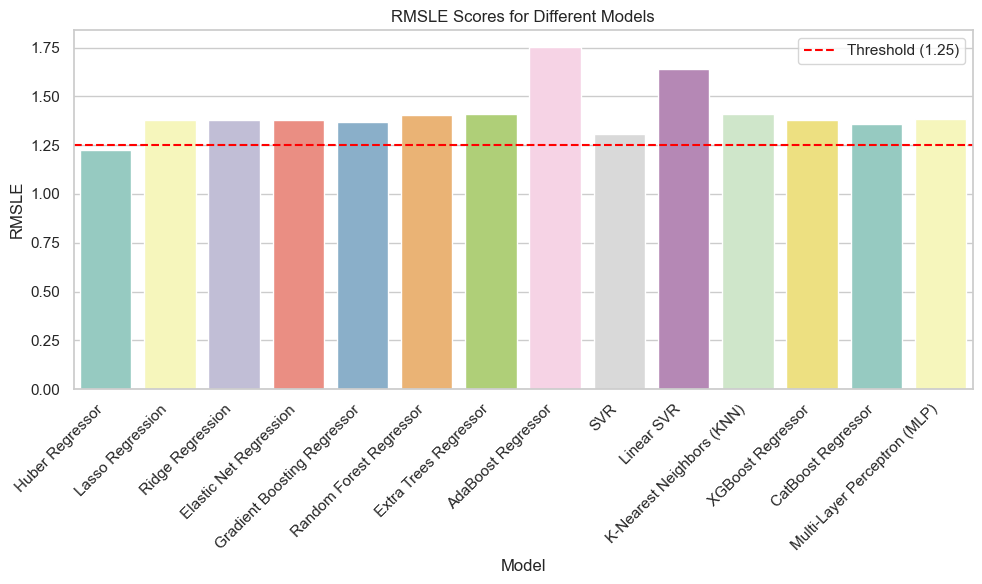

In [72]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
threshold = 1.25
ax = sns.barplot(x="Model Name", y="RMSLE", data=results_df, palette="Set3")
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel("Model")
plt.ylabel("RMSLE")
plt.title("RMSLE Scores for Different Models")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Multi Level Model Stacking

<p> Since most of the models aren't performing to expectations, we will generate level-1 predictions and store that to train another model, in this case, the best performing Huber Regressor to predict from the stacked prediction matrix, improving our scores, this can be done to multiple levels, we will stick to two. </p>

In [69]:
stacked_predictions = pd.DataFrame()

# Generate level-1 predictions using the previously trained models
for model_name, model in models.items():
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)
    
    # Ensure predictions and targets are non-negative
    Y_train_pred = np.abs(Y_train_pred)
    Y_test_pred = np.abs(Y_test_pred)
    
    # Store predictions in the stacked_predictions DataFrame
    stacked_predictions[model_name] = Y_test_pred

# Train a meta-model on the stacked predictions
meta_model = HuberRegressor(max_iter=10000)  # You can choose a different meta-model
meta_model.fit(stacked_predictions, Y_test)

# Make final predictions using the meta-model
final_predictions = meta_model.predict(stacked_predictions)

# Ensure predictions and targets are non-negative
final_predictions = np.abs(final_predictions)
Y_test = np.abs(Y_test)

# Calculate RMSLE for the stacked model
stacked_rmsle = np.sqrt(mean_squared_log_error(Y_test, final_predictions))
print(f"Stacked Model RMSLE = {stacked_rmsle:.4f}")

# Print RMSLE scores for each base model
results_df = pd.DataFrame(columns=["Model Name", "RMSLE"])
for model_name, model in models.items():
    Y_pred = model.predict(X_test)
    Y_pred = np.abs(Y_pred)
    
    rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
    print(f"{model_name}: RMSLE = {rmsle:.4f}")
    results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)

# Print the results DataFrame
print(results_df)

Stacked Model RMSLE = 1.2083
Huber Regressor: RMSLE = 1.2227
Lasso Regression: RMSLE = 1.3764
Ridge Regression: RMSLE = 1.3764
Elastic Net Regression: RMSLE = 1.3805
Gradient Boosting Regressor: RMSLE = 1.3660


/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/258

Random Forest Regressor: RMSLE = 1.4029


/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)


Extra Trees Regressor: RMSLE = 1.4095
AdaBoost Regressor: RMSLE = 1.7506


/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)


SVR: RMSLE = 1.3067
Linear SVR: RMSLE = 1.6380


/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)


K-Nearest Neighbors (KNN): RMSLE = 1.4120
XGBoost Regressor: RMSLE = 1.3771
CatBoost Regressor: RMSLE = 1.3596
Multi-Layer Perceptron (MLP): RMSLE = 1.3831
                      Model Name     RMSLE
0                Huber Regressor  1.222707
1               Lasso Regression  1.376366
2               Ridge Regression  1.376367
3         Elastic Net Regression  1.380477
4    Gradient Boosting Regressor  1.366018
5        Random Forest Regressor  1.402899
6          Extra Trees Regressor  1.409461
7             AdaBoost Regressor  1.750636
8                            SVR  1.306718
9                     Linear SVR  1.637997
10     K-Nearest Neighbors (KNN)  1.411952
11             XGBoost Regressor  1.377084
12            CatBoost Regressor  1.359585
13  Multi-Layer Perceptron (MLP)  1.383113


/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/2582128578.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({"Model Name": model_name, "RMSLE": rmsle}, ignore_index=True)
/var/folders/0n/rrvn4b1j24d2z9jl1cy985n80000gp/T/ipykernel_2776/258

In [ ]:
#we can see a clear improvement in the score as we stack the models into a metamodel of huber regressor,
#if we go down another level of stacking

In [70]:




X = df.drop(['id', 'cc_cons'], axis=1)
Y = df['cc_cons']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

base_models = [
    ("Huber Regressor", HuberRegressor(max_iter=10000)),
    ("Lasso Regression", Lasso()),
    ("Ridge Regression", Ridge()),
    ("Elastic Net Regression", ElasticNet()),
    ("Gradient Boosting Regressor", GradientBoostingRegressor()),
    ("Random Forest Regressor", RandomForestRegressor()),
    ("Extra Trees Regressor", ExtraTreesRegressor()),
    ("AdaBoost Regressor", AdaBoostRegressor()),
    ("SVR", SVR()),
    ("Linear SVR", LinearSVR()),
    ("K-Nearest Neighbors (KNN)", KNeighborsRegressor()),
    ("XGBoost Regressor", XGBRegressor(verbosity=0)),
    ("CatBoost Regressor", CatBoostRegressor(silent=True)),
    ("Multi-Layer Perceptron (MLP)", MLPRegressor(hidden_layer_sizes=(100, 50, 10), verbose=0))
]

stacking_layer1 = StackingRegressor(estimators=base_models, final_estimator=HuberRegressor(max_iter=10000))
stacking_layer1.fit(X_train, Y_train)

stacking_layer1_predictions = stacking_layer1.predict(X_test)
stacking_layer1_predictions = np.abs(stacking_layer1_predictions)
Y_test = np.abs(Y_test)

stacking_layer1_rmsle = np.sqrt(mean_squared_log_error(Y_test, stacking_layer1_predictions))
print(f"Stacking Layer 1 RMSLE = {stacking_layer1_rmsle:.4f}")


additional_base_models = [
    ("New Base Model 1", RandomForestRegressor()),  
    ("New Base Model 2", SVR()),                  
]

stacking_layer2 = StackingRegressor(estimators=additional_base_models, final_estimator=HuberRegressor(max_iter=10000))

stacking_layer2.fit(stacking_layer1_predictions.reshape(-1, 1), Y_test)

final_stacked_predictions = stacking_layer2.predict(stacking_layer1_predictions.reshape(-1, 1))

final_stacked_predictions = np.abs(final_stacked_predictions)
Y_test = np.abs(Y_test)
final_stacked_rmsle = np.sqrt(mean_squared_log_error(Y_test, final_stacked_predictions))
print(f"Final Stacked Model RMSLE = {final_stacked_rmsle:.4f}")


/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jessenth.ebenezer/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarn

Stacking Layer 1 RMSLE = 1.2170
Final Stacked Model RMSLE = 1.1798


#### So we can see an improvement in our score here. Based on the findings of the experiments executed in this notebook, the final stacked model is found in solution.py in the parent directory, thank you for reading!